In [1]:
# Repository bootstrap: make local packages importable from any notebook working directory.
from pathlib import Path
import sys
_HERE = Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'publication_reconstruction').is_dir() and (p / 'data').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root from the notebook working directory.')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))


In [2]:
from pathlib import Path

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in (p, *p.parents):
        if (candidate / "CITATION.cff").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Repository root not found")

REPO_ROOT = find_repo_root()


# P01 Showcase — Spectroscopy Reconstruction

Published spectral constraints → synthetic CCD-like spectrum → Gaussian fit → Eq. (3)/(11) quadrature resolution correction → Doppler temperature consistency check → Monte-Carlo uncertainty → source comparison.

In [3]:
import pandas as pd
from publication_reconstruction.advanced import reconstruct_paper1_full
df=pd.read_csv(REPO_ROOT / "data/publication_reconstruction/paper1_spectroscopy.csv")
result,spectra=reconstruct_paper1_full(df, mc=100)
result[["ion","reported_temperature_eV","consistency_check_temperature_eV","uncertainty_eV","relative_difference_pct"]]

,ion,reported_temperature_eV,consistency_check_temperature_eV,uncertainty_eV,relative_difference_pct
0,N III,34.44,37.452607,0.063755,8.747406
1,O V,85.75,89.251821,0.094644,4.083756
2,Cr I,4.53,15.541348,0.105223,243.076115
3,C II,28.24,30.817635,0.041379,9.127603
4,Mo I,4.50,24.927957,0.216226,453.954609
5,O II,32.59,35.812830,0.059294,9.889016
6,Ar II,24.35,32.490082,0.096746,33.429497
7,N II,30.06,32.937430,0.043223,9.572289
8,Ni I,6.48,18.353874,0.113990,183.238794
9,Ti I,3.66,13.246316,0.079673,261.921207


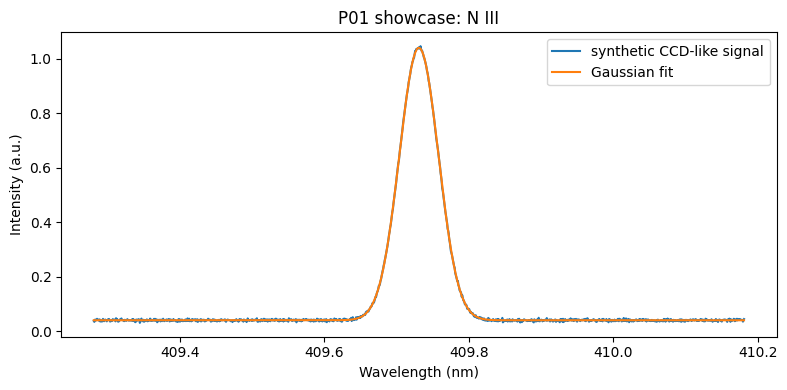

In [4]:
import matplotlib.pyplot as plt
ion,x,y,popt=spectra[0]
plt.figure(figsize=(8,4))
plt.plot(x,y,label="synthetic CCD-like signal")
plt.plot(x, popt[0]+popt[1]*__import__("numpy").exp(-0.5*((x-popt[2])/popt[3])**2), label="Gaussian fit")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Intensity (a.u.)"); plt.title(f"P01 showcase: {ion}"); plt.legend(); plt.tight_layout()